In [1]:
#Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.figsize'] = (8,5)
sns.set_style("whitegrid")

In [2]:

#Setp-2 Load Dataset

df = pd.read_csv("amazon_products.csv")   # update filename if different

df.head()

,asin,title,imgUrl,productURL,stars,reviews,price,listPrice,category_id,isBestSeller,boughtInLastMonth
0,B014TMV5YE,"Sion Softside Expandable Roller Luggage, Black...",https://m.media-amazon.com/images/I/815dLQKYIY...,https://www.amazon.com/dp/B014TMV5YE,4.5,0,139.99,0.00,104,False,2000
1,B07GDLCQXV,Luggage Sets Expandable PC+ABS Durable Suitcas...,https://m.media-amazon.com/images/I/81bQlm7vf6...,https://www.amazon.com/dp/B07GDLCQXV,4.5,0,169.99,209.99,104,False,1000
2,B07XSCCZYG,Platinum Elite Softside Expandable Checked Lug...,https://m.media-amazon.com/images/I/71EA35zvJB...,https://www.amazon.com/dp/B07XSCCZYG,4.6,0,365.49,429.99,104,False,300
3,B08MVFKGJM,Freeform Hardside Expandable with Double Spinn...,https://m.media-amazon.com/images/I/91k6NYLQyI...,https://www.amazon.com/dp/B08MVFKGJM,4.6,0,291.59,354.37,104,False,400
4,B01DJLKZBA,Winfield 2 Hardside Expandable Luggage with Sp...,https://m.media-amazon.com/images/I/61NJoaZcP9...,https://www.amazon.com/dp/B01DJLKZBA,4.5,0,174.99,309.99,104,False,400


In [3]:
# step-3 Basic Data Info
df.shape

df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1426337 entries, 0 to 1426336
Data columns (total 11 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   asin               1426337 non-null  object 
 1   title              1426336 non-null  object 
 2   imgUrl             1426337 non-null  object 
 3   productURL         1426337 non-null  object 
 4   stars              1426337 non-null  float64
 5   reviews            1426337 non-null  int64  
 6   price              1426337 non-null  float64
 7   listPrice          1426337 non-null  float64
 8   category_id        1426337 non-null  int64  
 9   isBestSeller       1426337 non-null  bool   
 10  boughtInLastMonth  1426337 non-null  int64  
dtypes: bool(1), float64(3), int64(3), object(4)
memory usage: 110.2+ MB


,stars,reviews,price,listPrice,category_id,boughtInLastMonth
count,1.426337e+06,1.426337e+06,1.426337e+06,1.426337e+06,1.426337e+06,1.426337e+06
mean,3.999512e+00,1.807508e+02,4.337540e+01,1.244916e+01,1.237409e+02,1.419823e+02
std,1.344292e+00,1.761453e+03,1.302893e+02,4.611198e+01,7.311273e+01,8.362720e+02
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
25%,4.100000e+00,0.000000e+00,1.199000e+01,0.000000e+00,6.500000e+01,0.000000e+00
50%,4.400000e+00,0.000000e+00,1.995000e+01,0.000000e+00,1.200000e+02,0.000000e+00
75%,4.600000e+00,0.000000e+00,3.599000e+01,0.000000e+00,1.760000e+02,5.000000e+01
max,5.000000e+00,3.465630e+05,1.973181e+04,9.999900e+02,2.700000e+02,1.000000e+05


In [4]:
# step-4 Column Names (Verification)
df.columns

Index(['asin', 'title', 'imgUrl', 'productURL', 'stars', 'reviews', 'price',
       'listPrice', 'category_id', 'isBestSeller', 'boughtInLastMonth'],
      dtype='object')

In [5]:
# step-5 missing values analysis
df.isnull().sum().sort_values(ascending=False)

title                1
asin                 0
imgUrl               0
productURL           0
stars                0
reviews              0
price                0
listPrice            0
category_id          0
isBestSeller         0
boughtInLastMonth    0
dtype: int64

In [6]:
# step-6 handlie missing values (important)
df = df.dropna(subset=['stars', 'price', 'listPrice', 'reviews'])

In [7]:
# step-7 data type conversion
df['stars'] = df['stars'].astype(float)
df['reviews'] = df['reviews'].astype(int)
df['price'] = df['price'].astype(float)
df['listPrice'] = df['listPrice'].astype(float)
df['boughtInLastMonth'] = df['boughtInLastMonth'].astype(int)

In [8]:
# step-8 feature engineering (advanced step)
#Discount Amount

df['discount'] = df['listPrice'] -df['price']

#Discount Percentage

df['discount_percent'] = (df['discount'] / df['listPrice']) * 100


In [9]:
# step-9 outlier treatment 
df = df[(df['price'] > 0) & (df['price'] < df['price'].quantile(0.99))]
df = df[(df['reviews'] < df['reviews'].quantile(0.99))]

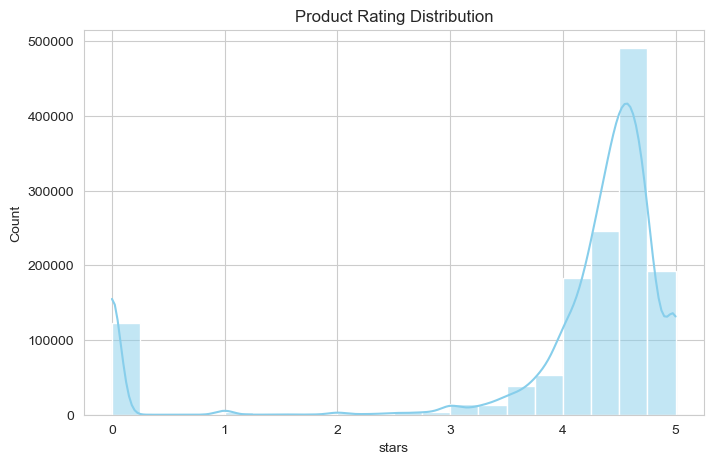

In [10]:
# Exploratory Data Analysis
#-------------------------------

# Step-10 rating (stars) distribution
plt.figure(figsize=(8,5))
sns.histplot(df['stars'], bins=20, kde=True, color='skyblue')
plt.title("Product Rating Distribution")
plt.show()


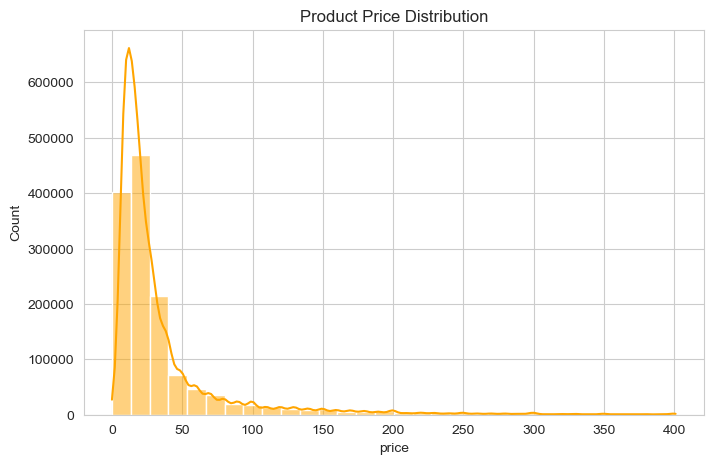

In [11]:
# Step-11 Price Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True, color='orange')
plt.title("Product Price Distribution")
plt.show()

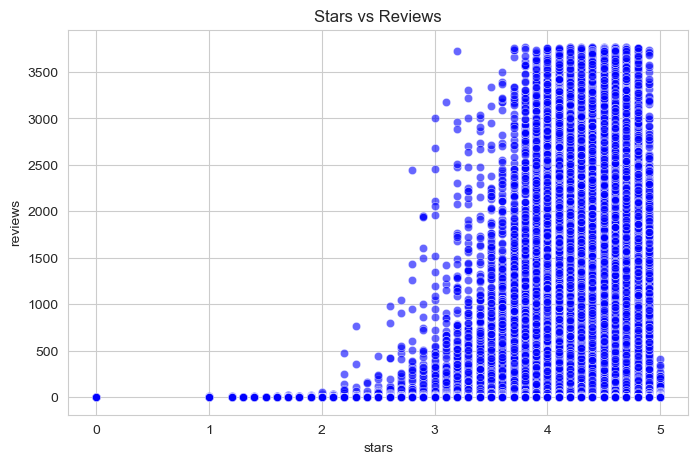

In [12]:
# Step-12 Reviews vs Stars
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='stars', y='reviews', color='blue', alpha=0.6)
plt.title("Stars vs Reviews")
plt.show()

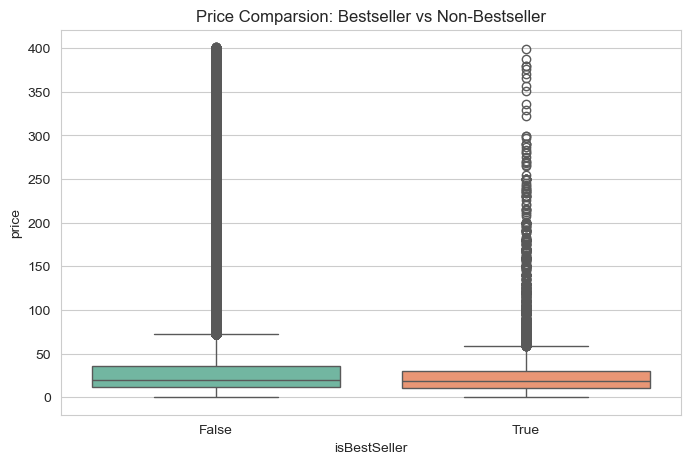

In [13]:
# Step-13 Bestseller vs Non-Bestselle
plt.figure(figsize=(8,5))
sns.boxplot(
    data=df,
    x='isBestSeller',
    y='price',
    hue='isBestSeller',
    palette='Set2',
    legend=False
)
plt.title("Price Comparsion: Bestseller vs Non-Bestseller")
plt.show()

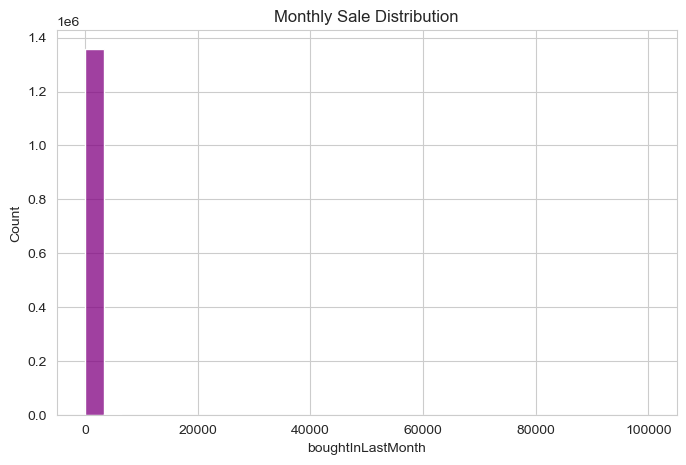

In [14]:
# Step-14 Monthly Sale Analysis
plt.figure(figsize=(8,5))
sns.histplot(df['boughtInLastMonth'], bins=30, color='purple')
plt.title("Monthly Sale Distribution")
plt.show()

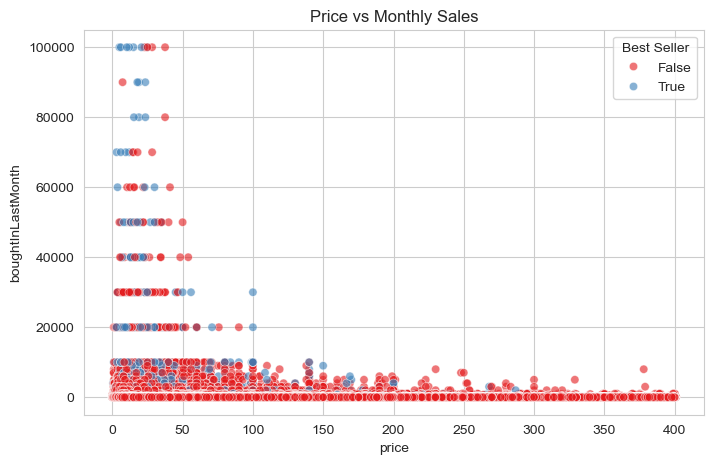

In [15]:
# step-15 # 15. Price vs Monthly Sales
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='price',
    y='boughtInLastMonth',
    hue='isBestSeller',
    palette='Set1',
    alpha=0.6
)
plt.legend(title='Best Seller', loc='upper right')
plt.title("Price vs Monthly Sales")
plt.show()

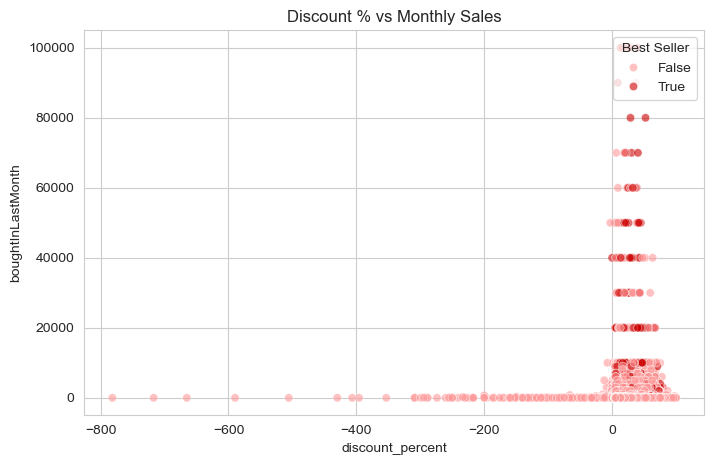

In [16]:
#Step-16 Discount Impact on Sales
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x='discount_percent',
    y='boughtInLastMonth',
    hue='isBestSeller',
    palette=['#ff9999', '#cc0000'],
    alpha=0.6
)
plt.legend(title='Best Seller', loc='upper right')
plt.title("Discount % vs Monthly Sales")
plt.show()

In [18]:
# Step-17 Bestelling products Analysis
print(df.groupby('isBestSeller')[['price','stars','reviews','boughtInLastMonth']].mean())

                  price     stars     reviews  boughtInLastMonth
isBestSeller                                                    
False         35.440853  4.006481   73.957195         124.280477
True          28.828856  4.490299  127.807024        2221.621622


In [20]:
#Step-18 Top Selling Products
top_products = df.sort_values(by='boughtInLastMonth', ascending=False).head(10)
print(top_products[['title','price','stars','reviews','boughtInLastMonth']])

                                                     title  price  stars  \
1016564  Nespresso Capsules VertuoLine, Medium and Dark...  37.50    4.8   
466031   Hismile v34 Colour Corrector, Tooth Stain Remo...  20.69    3.4   
331040   Amazon Basics 2-Ply Paper Towels, Flex-Sheets,...  22.86    4.2   
331038   Stardrops - The Pink Stuff - The Miracle All P...   4.99    4.4   
1227843  COSRX Snail Mucin 96% Power Repairing Essence ...  15.00    4.6   
1227844  Mighty Patch Original from Hero Cosmetics - Hy...  11.97    4.5   
331037   Amazon Brand - Presto! Flex-a-Size Paper Towel...  28.28    4.7   
1227845  Neutrogena Cleansing Fragrance Free Makeup Rem...  10.27    4.8   
331036   Bounty Quick Size Paper Towels, White, 8 Famil...  24.42    4.8   
1009205  LMNT Zero-Sugar Electrolytes - Variety Salt - ...  25.00    4.5   

         reviews  boughtInLastMonth  
1016564        0             100000  
466031         0             100000  
331040         0             100000  
331038     

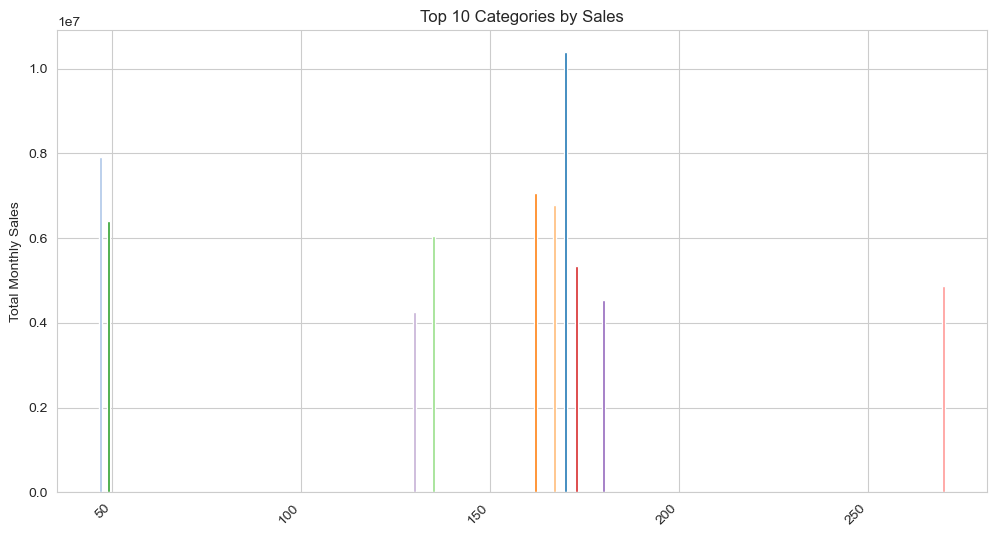

In [24]:
# Step-19 category-Level Analysis (Colorful Bar Plot)
top_categories = df.groupby('category_id')['boughtInLastMonth'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
colors = plt.cm.tab20.colors
plt.bar(top_categories.index, top_categories.values, color=colors[:len(top_categories)])
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Categories by Sales")
plt.ylabel("Total Monthly Sales")
plt.ylabel("Total Monthly Sales")
plt.show()

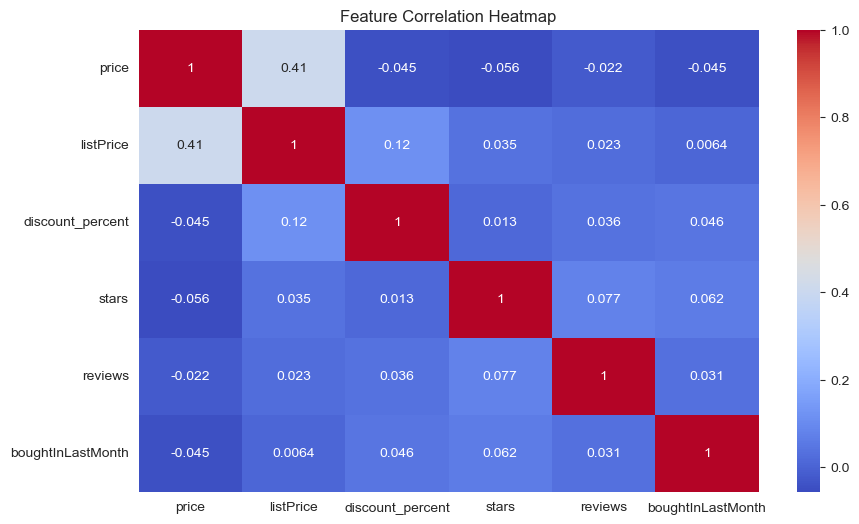

In [27]:
# Step-20 Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(
    df[['price','listPrice','discount_percent','stars','reviews','boughtInLastMonth']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Feature Correlation Heatmap")
plt.show()